<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F09_review_run.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 09 · Review a finished run — leaderboard, distribution, ensemble lift, timeline

The read-only, finished-run half of the job-review pair (its live launch+monitor is [08](08_run_and_monitor.ipynb)). Point it at any completed `run_id` — the one [08](08_run_and_monitor.ipynb) just launched, or any run in the registry — and it answers *how did it do?* in data-science detail:

- **Leaderboard** — every model best-first in the run's own decision metric, base vs. ensemble.
- **Metric distribution** — each model's spread across every series (p10–p90 with a median dot), read server-side so it holds at 100k+.
- **Ensemble lift** — did combining beat the best single model?
- **Execution timeline** — the family DAG over wall-clock: which family set the run's duration.

The whole layer is keyed on a bare `run_id` — the run *is* its config, so this reads the run's own `raw_config` back to recover what it planned (models per family, decision metric, ensembles) and scores against that. It **runs nothing** — no config, no `main.run`, no compute; it only reads the registry, so it's cheap, re-runnable, and safe to point at a run that's still finishing.

## Get the code (cloud runtimes only)

On a cloud notebook (Colab Enterprise, Vertex Workbench) this clones or updates the repo so you're on the latest `src/`. **Skip it in a local clone** — it's a no-op guarded on the package already being importable.

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
# Uses uv (Colab ships it; we install it if missing) to install the frozen lock into a PRIVATE
# prefix, then puts that prefix + src/ first on sys.path. Harmless locally — if it already imports,
# no-op.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")

EXTRAS = []  # this notebook needs only the core (it reads the registry — no model stack)

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:  # Colab Enterprise ships uv; install it if this runtime doesn't
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    # Resolve the checked-in lock to a requirements file (no re-resolve), then install EXACTLY
    # that set into this kernel — the same versions the container + packed-venv are built from.
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags,
         "-o", reqs],
        cwd=REPO_DIR, check=True,
    )
    # Install the LOCKED set into a PRIVATE directory (not the runtime's system site-packages),
    # then put it FIRST on sys.path. Managed images (Colab Enterprise, Vertex) ship numpy 2.x that
    # can't be cleanly downgraded in place: uv skips the version-satisfied packages it can't fully
    # uninstall, so numpy-2 .so files end up beside numpy-1 python and `import numpy` dies with
    # "dtype size changed, Expected 96 ... got 88". Installing to a separate prefix and SHADOWING the
    # base packages (never touching them) gives this kernel a clean, self-consistent numpy 1.26.4 —
    # the same set every other surface runs — with zero risk of a mixed install.
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    # src/ carries our package; `target` carries its locked deps. Both go ahead of the base image's
    # site-packages so imports resolve to the versions we installed, not the runtime's.
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))

## Resolve the deployment (live GCP)

`Settings.resolve()` reads the `SF_*` environment — the *same* identity every writer uses. Required: `SF_PROJECT_ID`, `SF_CONNECTION`, `SF_WAREHOUSE_URI`; `SF_DATASET_ID`/`SF_REGION` default. This notebook only *reads* the run registry (via the `scale_forecasting.review` layer), so it never writes.

In [2]:
import pandas as pd
from google.cloud import bigquery

from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print("deployment:", DATASET, "region:", settings.region)

deployment: statmike-scale-forecasting.scale_forecasting region: us-central1


## Parameters — the run_id to review

Set `RUN_ID` to the finished run you want to review — the one [08](08_run_and_monitor.ipynb) launched, or any run below. Leave it `None` and the discovery cell picks the most recent run for you.

In [3]:
# === Parameters — edit me ===============================================
RUN_ID = None  # e.g. "all-families-100k-050eee3e0a6b"; None → auto-pick most recent below
# ========================================================================

## Discover recent run_ids

The most recent runs with their `status` and scale — copy a `COMPLETED` `run_id` into the cell above (a run with `backtest` on has the full metric view; the 100k default turns backtest off, so those show the leaderboard + timeline only). If you left `RUN_ID = None`, the next cell auto-selects the top row.

In [4]:
recent = client.query(
    f"SELECT run_id, created_at, status, python_runtime, n_series, n_models "
    f"FROM `{DATASET}.v_run_summary` "
    f"ORDER BY created_at DESC LIMIT 25"
).result().to_dataframe()

if RUN_ID is None and not recent.empty:
    RUN_ID = recent.iloc[0]["run_id"]
    print(f"RUN_ID not set — auto-selected most recent: {RUN_ID}")
elif RUN_ID is None:
    print("No runs found in the registry yet — run one first (see notebook 08), then re-run.")
else:
    print(f"reviewing: {RUN_ID}")
recent

RUN_ID not set — auto-selected most recent: nb02-bq-native-1789913623-ece832b57959


,run_id,created_at,status,python_runtime,n_series,n_models
0,nb02-bq-native-1789913623-ece832b57959,2026-09-20 14:13:56.285335+00:00,COMPLETED,spark,100,2
1,smoke-15-airflow-multi-engine-60d76b813135,2026-09-20 00:07:53.763791+00:00,COMPLETED,spark,200,5
2,sig4-11h-35c7c0d03d55,2026-09-19 13:06:45.527759+00:00,FAILED,spark,100,1
3,all-families-10k-a0f6797d69c1,2026-09-16 19:16:36.697319+00:00,COMPLETED,ray,10000,7
4,all-families-10k-full-92a6080476d7,2026-09-16 13:32:55.438265+00:00,COMPLETED,ray,10000,7
5,ray-gpu-demo-fa53d37c8122,2026-09-15 22:07:40.625871+00:00,COMPLETED,ray,6,4
6,ray-cpu-demo-1650659c3c20,2026-09-15 21:47:01.356093+00:00,COMPLETED,ray,6,4
7,bq-native-demo-afdc0507e8b5,2026-09-15 21:44:38.320827+00:00,COMPLETED,spark,100,2
8,orphan-11h-28d65b370b23,2026-09-15 20:57:19.882418+00:00,COMPLETED,ray,100,1
9,deadlock-11h-d09a1bf19be9,2026-09-15 20:22:35.249528+00:00,FAILED,ray,100,1


## Review — how did it do?

`review_run(run_id)` reads the leaderboard, the cross-series metric aggregates, and the prediction counts, and returns a `RunReview`: every model best-first in the run's own `decision_metric`, the best model per family and overall, the ensembles, and each ensemble's lift over the best base model. When a run had no backtest (no aggregates) it falls back to the leaderboard, scoring on WAPE.

> Review a run once it's `COMPLETED`. On a run that turned backtest off for speed (the 100k default), the metric panel is empty — the leaderboard and timeline below are still the story; turn backtest on in a demo config to populate the accuracy view.

In [5]:
from scale_forecasting.review import review_run

review = review_run(RUN_ID, settings=settings)
print(f"{review.run_id} — status={review.status} — decision metric: {review.decision_metric} "
      f"(lower is better) — {review.n_series} series\n")

if review.best_overall is not None:
    b = review.best_overall
    print(f"best overall: {b.model_type} ({b.family}) — {review.decision_metric}={b.score:.4g}")
    print("best per family:")
    for fam, m in review.best_per_family.items():
        print(f"  {fam:<14} {m.model_type:<16} {review.decision_metric}={m.score:.4g}")
else:
    print("no scored base model (this run has no backtest) — see the leaderboard/timeline below.")

nb02-bq-native-1789913623-ece832b57959 — status=COMPLETED — decision metric: wape (lower is better) — 100 series

best overall: timesfm (native) — wape=0.3559
best per family:
  native         timesfm          wape=0.3559


In [6]:
# The full model board: every model (base + ensemble) best-first, with the run's decision-metric
# score, per-cell fit time, and forecast-row count. n_predictions == 0 flags a model that scored
# metadata but produced no forecasts (a fully-failed fit).
board = pd.DataFrame([
    {
        "model_type": m.model_type,
        "family": m.family,
        "is_ensemble": m.is_ensemble,
        "compute_engine": m.compute_engine,
        "n_series": m.n_series,
        review.decision_metric: m.score,
        "median_fit_seconds": m.median_fit_seconds,
        "no_artifact_rate": m.no_artifact_rate,
        "n_predictions": m.n_predictions,
    }
    for m in review.models
])
board

,model_type,family,is_ensemble,compute_engine,n_series,wape,median_fit_seconds,no_artifact_rate,n_predictions
0,timesfm,native,False,bigquery,100,0.355866,None,1.0,2800
1,arima_plus,native,False,bigquery,100,0.384481,None,1.0,2800


### Leaderboard

Scored models ranked, best (lowest decision-metric error) on top, coloured base vs. ensemble. The score is labelled at each bar end; a legend appears when both base models and ensembles are present. Unscored models (no backtest) are dropped from the chart.

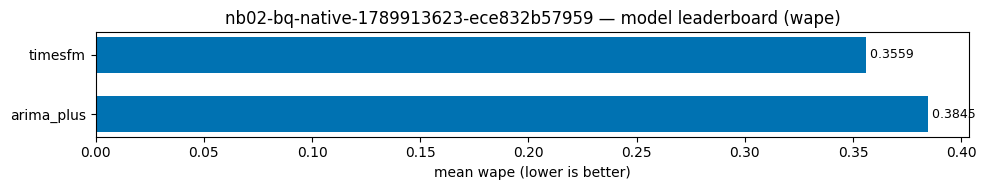

In [7]:
import matplotlib.pyplot as plt

from scale_forecasting.review import plot_leaderboard

plot_leaderboard(review)
plt.tight_layout()
plt.show()

### Metric distribution across series

The mean hides the tail. This shows each model's spread of the decision metric across every series — a line from the 10th to the 90th cross-series percentile with a dot at the median — read straight off the server-side aggregates, so it holds at 100k+ series without pulling per-series rows. A model can win on the mean and still be wide (unreliable) in the tail; here you see it.

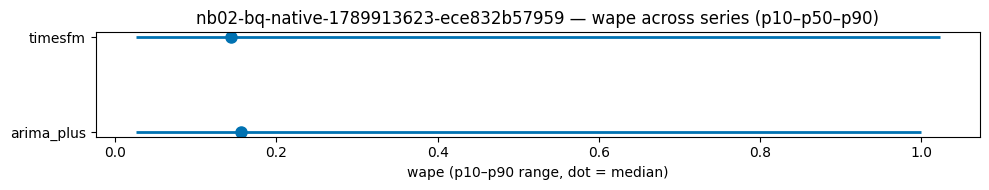

In [8]:
from scale_forecasting.review import plot_metric_distribution

plot_metric_distribution(review)
plt.tight_layout()
plt.show()

### Ensemble lift

The question every ensemble has to answer: *did combining beat the best single model?* Each ensemble's `lift` is `best_base_score − score` in the decision metric (positive = the ensemble is better, since lower error is better); `lift_pct` is that as a fraction of the base score. Best lift first — a negative lift means the ensemble did worse than just picking the champion.

In [9]:
if review.ensemble_lift:
    lift = pd.DataFrame([
        {
            "ensemble": e.model_type,
            "score": e.score,
            "best_base_model": e.best_base_model,
            "best_base_score": e.best_base_score,
            "lift": e.lift,
            "lift_pct": e.lift_pct,
        }
        for e in review.ensemble_lift
    ])
    display(lift)
else:
    print("No ensemble lift to report — this run has no scored ensemble (or no scored base model "
          "to compare against).")

No ensemble lift to report — this run has no scored ensemble (or no scored base model to compare against).


## Execution timeline — the family DAG over wall-clock

The waterfall of *when* things ran, reusing the SDK's trace builder. `build_trace_frame` stacks the per-family job spans (`v_run_jobs`) and the per-cell timing brackets (`forecast_metadata`) into one long-form frame; `plot_trace` renders it as a Gantt — each family job on its own lane, the cells that ran under it on worker lanes below. This is where you see a family's job overlap the next, and which family set the run's wall-clock. (Cell rows are capped for a bounded read; the per-job lanes are the whole-run view.)

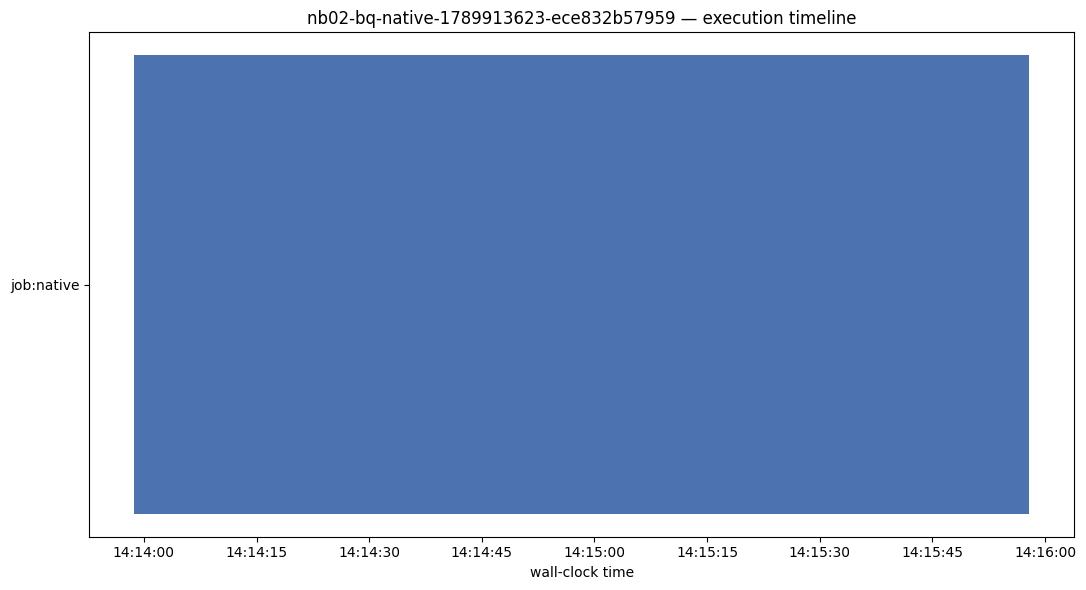

,kind,lane,label,start,end,duration_s,status,runtime,model_type,ts_id
0,job,native,native,2026-09-20 14:13:58.678921+00:00,2026-09-20 14:15:57.929102+00:00,119.250181,COMPLETED,bigquery,None,None


In [10]:
from scale_forecasting.registry.jobs import read_run_jobs
from scale_forecasting.registry.reads import read_cell_timing
from scale_forecasting.sdk import build_trace_frame, plot_trace

job_rows = read_run_jobs(RUN_ID, settings=settings)
cell_rows = read_cell_timing(RUN_ID, settings=settings)
frame = build_trace_frame(job_rows, cell_rows)

if not frame.empty:
    plot_trace(frame, title=f"{RUN_ID} — execution timeline")
    plt.tight_layout()
    plt.show()
else:
    print(f"No timed rows for {RUN_ID} — older runs predate the wall-clock trace columns, or the "
          "run hasn't recorded any job/cell brackets yet.")
frame.head()